In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import geopandas as gpd
pd.set_option('display.max_columns', None)

In [21]:
data2017 = pd.read_csv("donnees/élections/leg2017comm.csv", delimiter=",", low_memory=False)
data2017 = data2017[data2017["dep"] == "29"]
data2017["codecommune"] = data2017["codecommune"].astype(int)

data2022 = pd.read_csv("donnees/élections/leg2022comm.csv", delimiter=",", low_memory=False)
data2022 = data2022[data2022["dep"] == "29"]
data2022["codecommune"] = data2022["codecommune"].astype(int)

<Axes: >

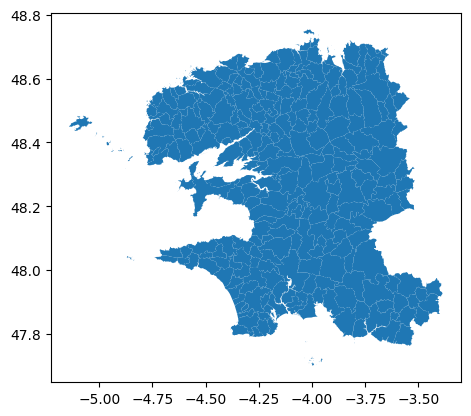

In [22]:
map = gpd.read_file("donnees/élections/communes-france.geojson")
map = map[map["dep_code"]=="29"]
map["com_code"] = map["com_code"].astype(int)
map.plot()

In [23]:
data_map2017 = map.merge(data2017, left_on="com_code", right_on="codecommune", how="left")
data_map2022 = map.merge(data2022, left_on="com_code", right_on="codecommune", how="left")

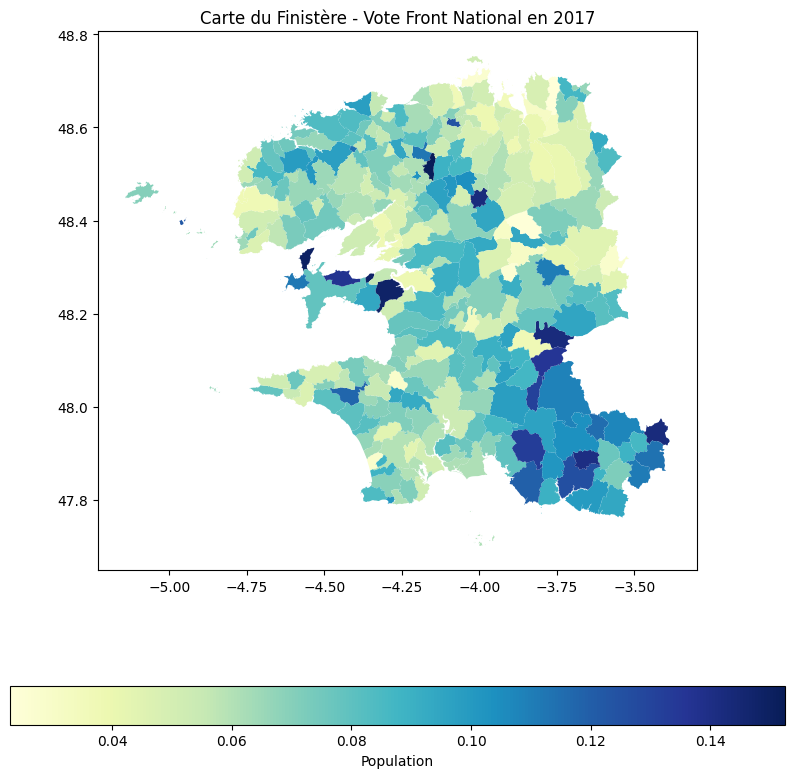

In [24]:
data_map2017["exprimes"] = data_map2017["exprimes"].astype(int).round()
data_map2017.head()
color = 'pvoixFN' # Attention, en 2017, c'était FN et non pas RN

fig, ax = plt.subplots(figsize=(10, 10))
data_map2017.plot(
    column=color,
    ax=ax,
    legend=True,
    legend_kwds={'label': "Population", 'orientation': "horizontal"},
    cmap='YlGnBu',
    missing_kwds={'color': 'lightgrey'}
)
plt.title("Carte du Finistère - Vote Front National en 2017")
plt.show()

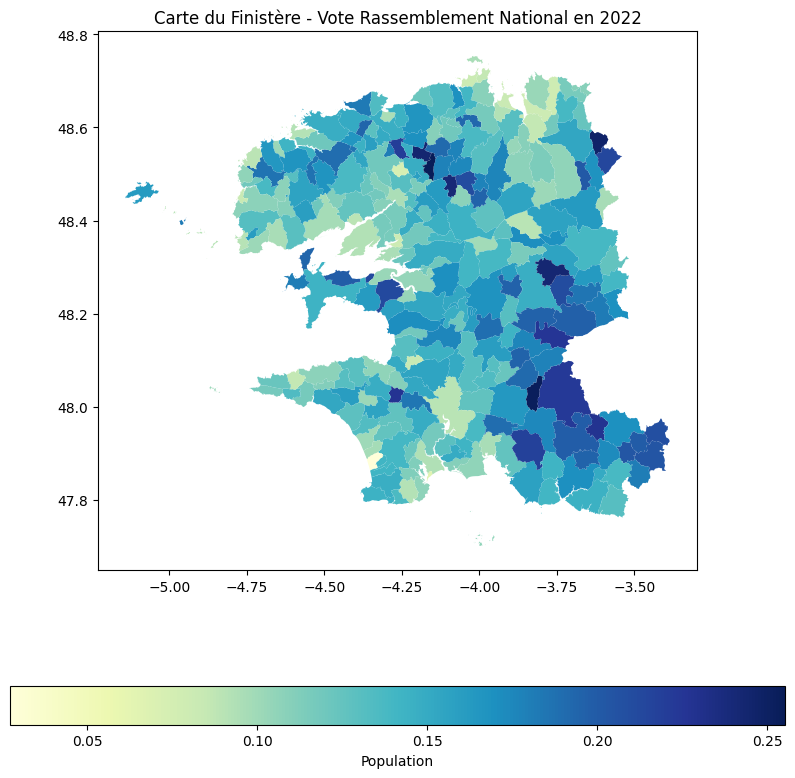

In [25]:
data_map2022["exprimes"] = data_map2022["exprimes"].astype(int).round()
data_map2022.head()
color = 'pvoixRN'

fig, ax = plt.subplots(figsize=(10, 10))
data_map2022.plot(
    column=color,
    ax=ax,
    legend=True,
    legend_kwds={'label': "Population", 'orientation': "horizontal"},
    cmap='YlGnBu',
    missing_kwds={'color': 'lightgrey'}
)
plt.title("Carte du Finistère - Vote Rassemblement National en 2022")
plt.show()